In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree, DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

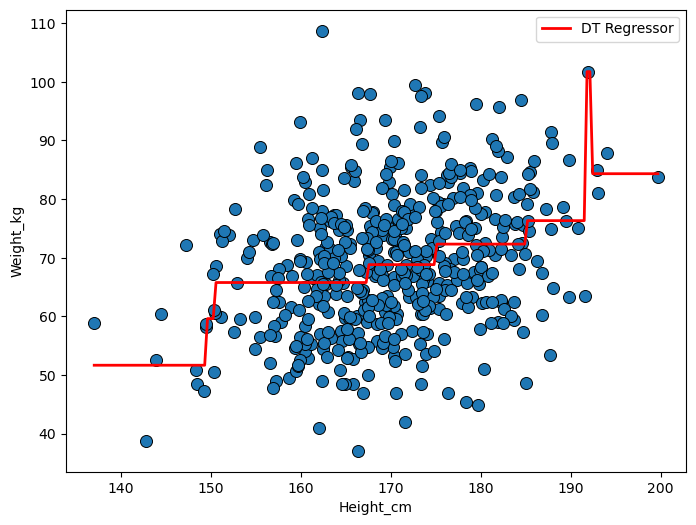

In [2]:
np.random.seed(26)
df = pd.DataFrame(
    np.random.multivariate_normal([170, 70], [[100, 50], [50, 144]], size=500).round(1),
    columns=['Height_cm', 'Weight_kg']
)
model = DecisionTreeRegressor(max_depth=3, criterion='absolute_error', random_state=26)
model.fit(df[['Height_cm']], df['Weight_kg'])
x = np.linspace(df['Height_cm'].min(), df['Height_cm'].max(), 200)
y_pred = model.predict(pd.DataFrame({'Height_cm': x}))

plt.figure(figsize=(8,6))
plt.plot(x, y_pred, color='red', linewidth=2, label='DT Regressor')
plt.legend()
sns.scatterplot(data=df, x='Height_cm', y='Weight_kg', s=75, edgecolor='k')
plt.show()

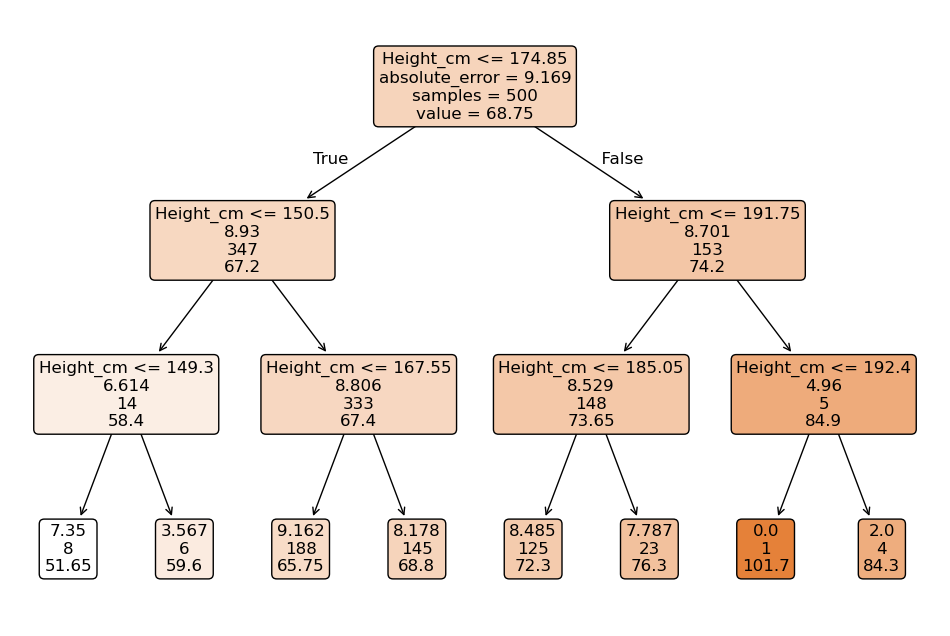

In [3]:
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=['Height_cm'],
    filled=True,
    fontsize=12,
    rounded=True,
    label='root'
)
plt.show()

In [4]:
df[(df['Height_cm'] <= 174.85) &
    (df['Height_cm'] <= 150.5) &
    (df['Height_cm'] <= 149.3)]

,Height_cm,Weight_kg
47,148.3,50.8
104,147.2,72.2
126,148.4,48.4
171,143.9,52.5
176,144.4,60.4
309,142.8,38.7
362,137.0,58.8
415,149.2,47.2


In [5]:
df[(df['Height_cm'] <= 174.35) &
    (df['Height_cm'] <= 151.25) &
    (df['Height_cm'] <= 148.65)].mean()

Height_cm    144.571429
Weight_kg     54.542857
dtype: float64

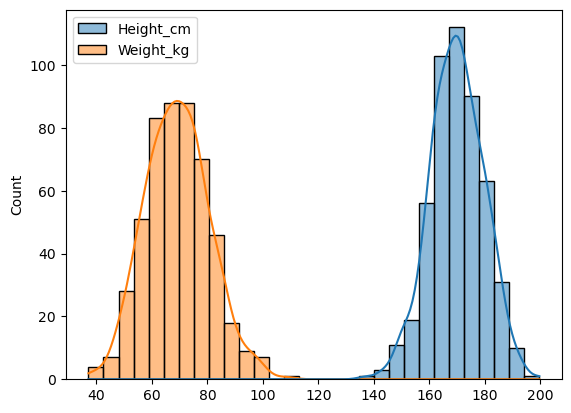

In [6]:
sns.histplot(
    data=df[['Height_cm', 'Weight_kg']],
    color='royalblue', 
    edgecolor='k', 
    bins=30, 
    kde=True
)
plt.show()


# Air Quality Dataset

In [11]:
file_path = r'C:\Users\hp\Downloads\air+quality\AirQualityUCI.csv'
df = pd.read_csv(file_path, sep=';', decimal=',')
df.drop(columns=['Unnamed: 15',	'Unnamed: 16'], inplace=True)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [12]:
df.isna().sum(), df.duplicated().sum()

(Date             114
 Time             114
 CO(GT)           114
 PT08.S1(CO)      114
 NMHC(GT)         114
 C6H6(GT)         114
 PT08.S2(NMHC)    114
 NOx(GT)          114
 PT08.S3(NOx)     114
 NO2(GT)          114
 PT08.S4(NO2)     114
 PT08.S5(O3)      114
 T                114
 RH               114
 AH               114
 dtype: int64,
 np.int64(113))

In [13]:
useful_columns = df.drop(columns=['Date', 'Time']).columns
df.replace(
    to_replace=-200,
    value=np.nan,
    inplace=True,
)
df.dropna(
    how='all',
    axis=1,
    inplace=True,
    ignore_index=True
)

df.dropna(
    how='all',
    subset=useful_columns,
    inplace=True,
    ignore_index=True
)
df.dropna(
    subset=['CO(GT)'],
    inplace=True, 
    ignore_index=True,
)

columns_to_fill = ['T', 'RH', 'AH']

for column in columns_to_fill:
    df[column] = df[column].ffill().bfill()

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Time'] = pd.to_datetime(df['Time'], format='%H.%M.%S')
df['Hour'] = df['Time'].dt.hour
df['Month'] = df['Date'].dt.month

In [14]:
df.isna().sum()

Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       330
NMHC(GT)         6784
C6H6(GT)          330
PT08.S2(NMHC)     330
NOx(GT)           413
PT08.S3(NOx)      330
NO2(GT)           416
PT08.S4(NO2)      330
PT08.S5(O3)       330
T                   0
RH                  0
AH                  0
Hour                0
Month               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Month'],
      dtype='object')

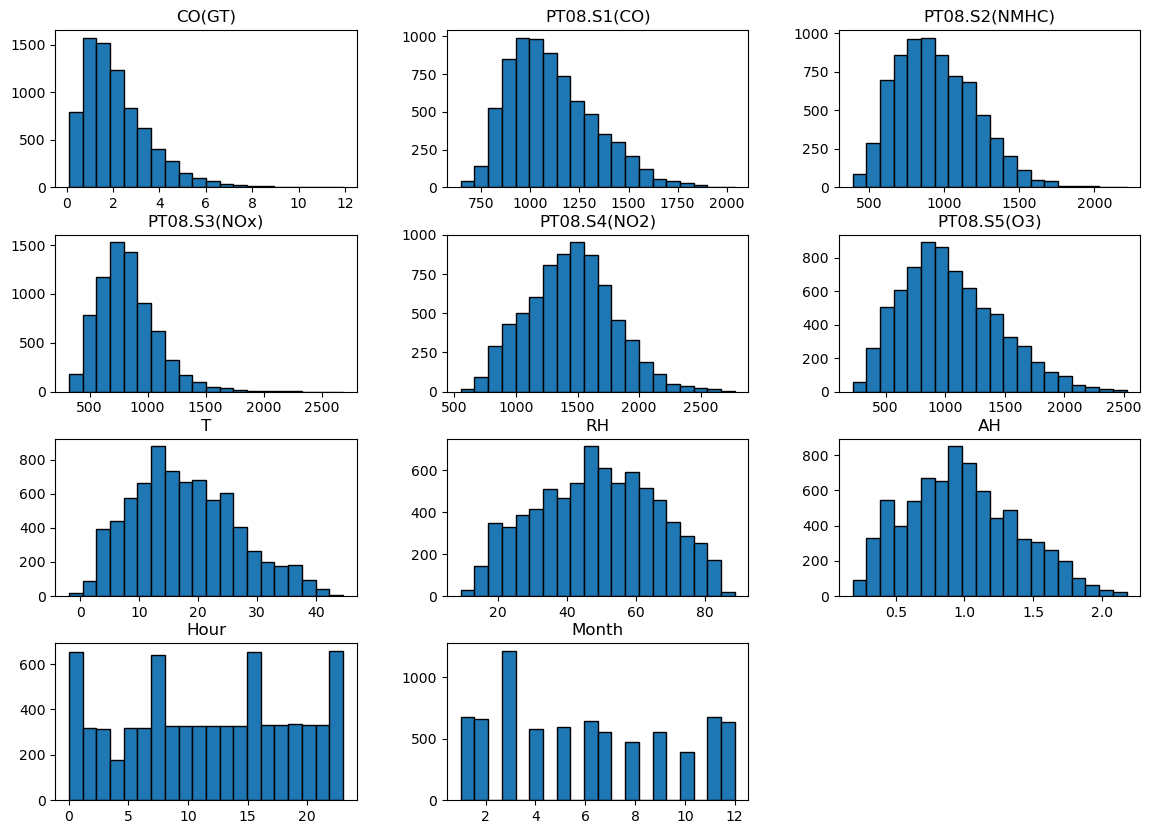

In [22]:
columns = df.drop(columns=['Date', 'Time', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']).columns
df[columns].hist(
    figsize=(14,10), edgecolor='k', 
    grid=False, bins=20
)
plt.show()

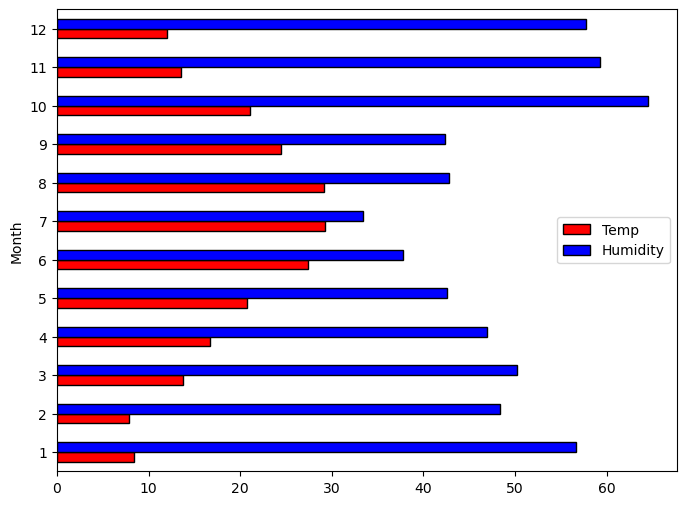

In [46]:
ax = df.groupby('Month')[['T','RH']].mean().plot(kind='barh', edgecolor='k', figsize=(8,6), color=['red', 'blue'])
ax.legend(['Temp', 'Humidity'])
plt.show()


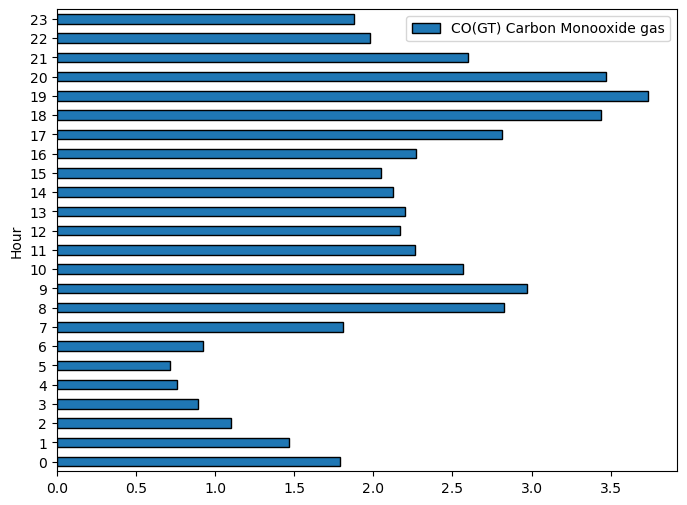

In [54]:
ax = df.groupby('Hour')['CO(GT)'].mean().plot(kind='barh', edgecolor='k', figsize=(8,6))
ax.legend(['CO(GT) Carbon Monooxide gas'])
plt.show()


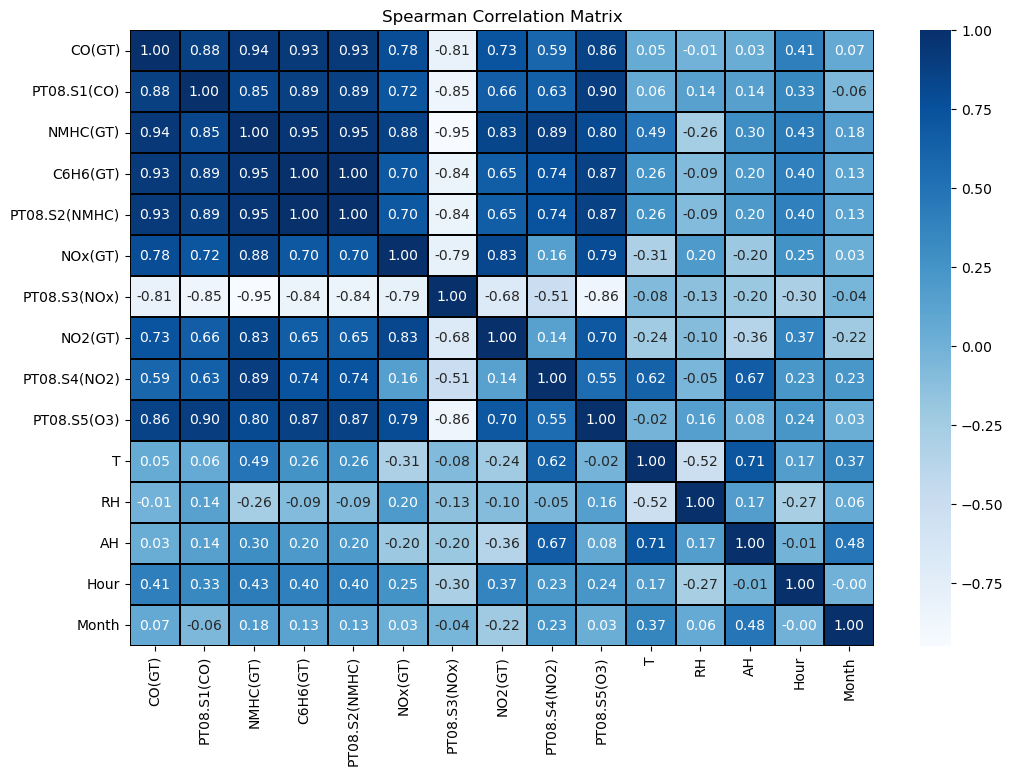

In [49]:
corr = df.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linecolor='k', linewidths=1.2)
plt.title('Spearman Correlation Matrix')
plt.show()

In [56]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Month'],
      dtype='object')

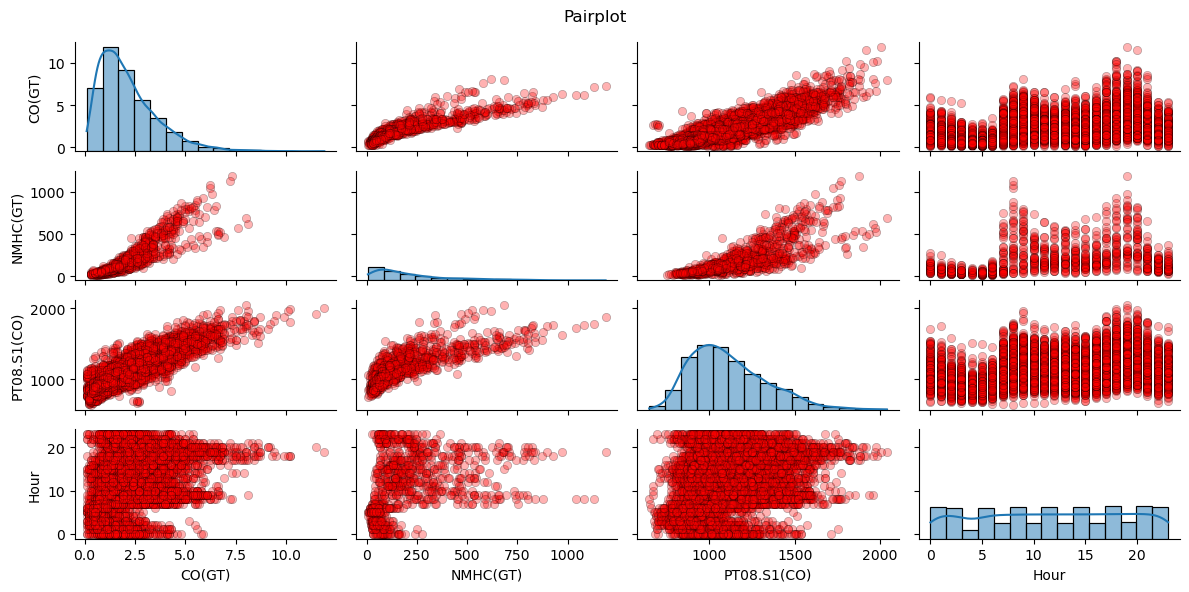

In [68]:
ax = sns.pairplot(
    data=df[['CO(GT)', 'NMHC(GT)', 'PT08.S1(CO)', 'Hour']],
    plot_kws={
        'alpha': 0.3,
        'color': 'red',
        'edgecolor': 'k'
    },
    diag_kws={
        'bins': 15,
        'kde': True
    }
)
ax.figure.set_size_inches(12,6)
plt.suptitle('Pairplot')
plt.tight_layout()
plt.show()

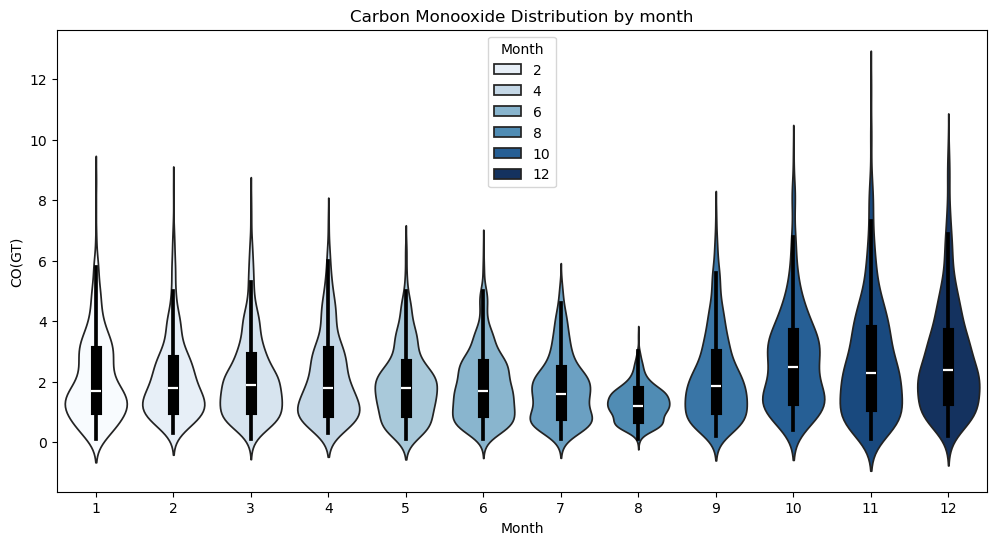

In [86]:
plt.figure(figsize=(12,6))
plt.title('Carbon Monooxide Distribution by month')
sns.violinplot(
    data=df,
    y='CO(GT)',
    x='Month',
    inner='box',
    hue='Month',
    palette='Blues',
    inner_kws={
        'color': 'k',
        'box_width': 8,
    }    
)
plt.show()

In [88]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Month'],
      dtype='object')

In [89]:
df.isna().sum()

Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       330
NMHC(GT)         6784
C6H6(GT)          330
PT08.S2(NMHC)     330
NOx(GT)           413
PT08.S3(NOx)      330
NO2(GT)           416
PT08.S4(NO2)      330
PT08.S5(O3)       330
T                   0
RH                  0
AH                  0
Hour                0
Month               0
dtype: int64

In [103]:
X = df.drop(
    columns=[
        'CO(GT)',
        'Date',
        'Time', 
        'NMHC(GT)',
        'C6H6(GT)',
        'NOx(GT)',
        'NO2(GT)',
    ]
)
y = df['CO(GT)']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=26, shuffle=True
)

model = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Model', DecisionTreeRegressor(criterion='squared_error'))
])
model.fit(X_train, y_train)

,steps,"[('Imputer', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,criterion,'squared_error'


In [96]:
r2_score(y_test, model.predict(X_test))

0.828784752202739

In [97]:
r2_score(y_train, model.predict(X_train))

0.9842314135104085

The model is overfitting

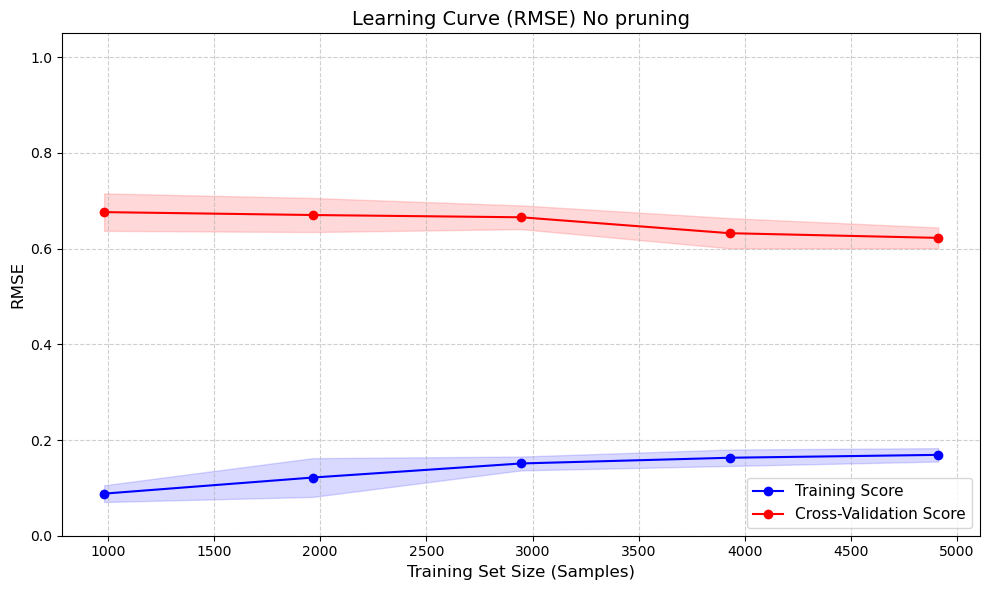

In [104]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error', 
    train_sizes=np.linspace(0.2, 1.0, 5)
)

train_mean = np.mean(-train_scores, axis=1)
train_std = np.std(-train_scores, axis=1)
test_mean = np.mean(-test_scores, axis=1)
test_std = np.std(-test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-Validation Score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='red')
plt.title('Learning Curve (RMSE) No pruning', fontsize=14)
plt.xlabel('Training Set Size (Samples)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()

In [106]:
model.named_steps['Model'].get_depth(), model.named_steps['Model'].get_n_leaves()

(27, np.int64(4265))

In [132]:
#Post pruning

X_train_imputed = model.named_steps['Imputer'].fit_transform(X_train)
tree = model.named_steps['Model']
tree.fit(X_train_imputed, y_train)
path = tree.cost_complexity_pruning_path(X_train_imputed, y_train)
alphas = path.ccp_alphas

In [133]:
path.impurities.mean()

np.float64(0.0519492108179282)

In [134]:
mean_squared_error(y_train, model.predict(X_train))

0.033013248628984096

In [135]:
alphas.max()

np.float64(1.094981200244482)

In [136]:
path.impurities.max()

np.float64(2.0936086218492296)

In [137]:
np.mean( (y_train.mean() - y_train)**2)

np.float64(2.093608621849242)

The last alpha removed all the leaf nodes except the root node

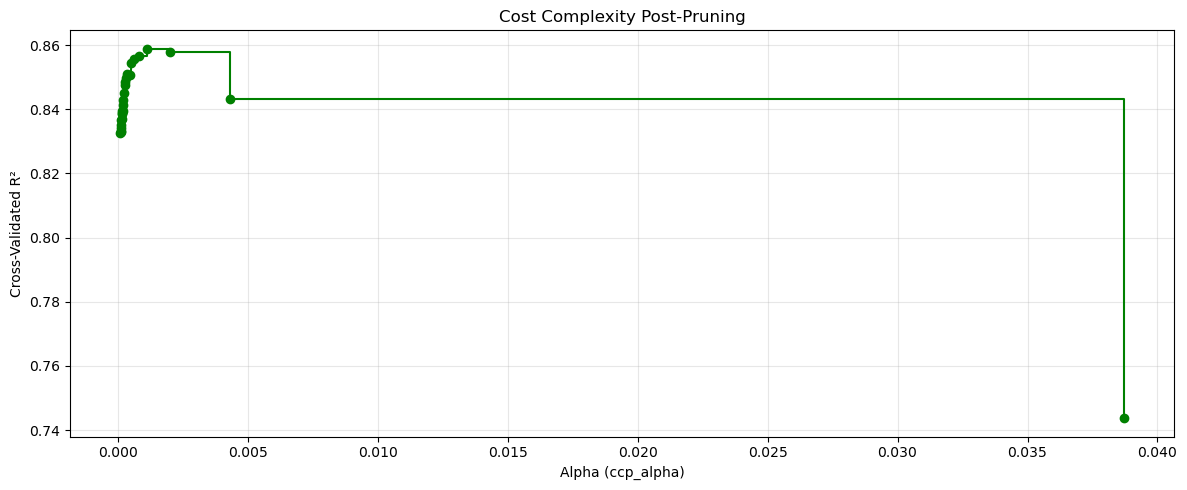

In [149]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

tree = DecisionTreeRegressor(criterion='squared_error', random_state=26)
tree.fit(X_train_imputed, y_train)

path = tree.cost_complexity_pruning_path(X_train_imputed, y_train)
alphas = np.unique(path.ccp_alphas[2:-2])
alphas = alphas[alphas >= 0.0001]
alphas = alphas[::15]

cv_scores = []
for alpha in alphas:
    decision_tree = Pipeline([
        ('Imputer', SimpleImputer(strategy='median')),
        ('Model', DecisionTreeRegressor(
            criterion='squared_error', 
            ccp_alpha=alpha, 
            random_state=26
        ))
    ])
    scores = cross_val_score(
        decision_tree,
        X_train,      
        y_train,
        cv=5,
        scoring='r2'
    )
    cv_scores.append(scores.mean())

plt.figure(figsize=(12, 5))
plt.plot(alphas, cv_scores, marker='o', drawstyle='steps-post', color='green')
plt.xlabel('Alpha (ccp_alpha)')
plt.ylabel('Cross-Validated R²')
plt.title('Cost Complexity Post-Pruning')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [152]:
best_alpha = alphas[np.argmax(cv_scores)]
best_model = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Model', DecisionTreeRegressor(criterion='squared_error', ccp_alpha=best_alpha))
])
best_model.fit(X_train, y_train)

,steps,"[('Imputer', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,criterion,'squared_error'


In [156]:
best_model.named_steps['Model'].get_depth(), best_model.named_steps['Model'].get_n_leaves()

(11, np.int64(56))

In [157]:
r2_score(y_train, best_model.predict(X_train)), r2_score(y_test, best_model.predict(X_test))

(0.8969083674002503, 0.8663294870374771)

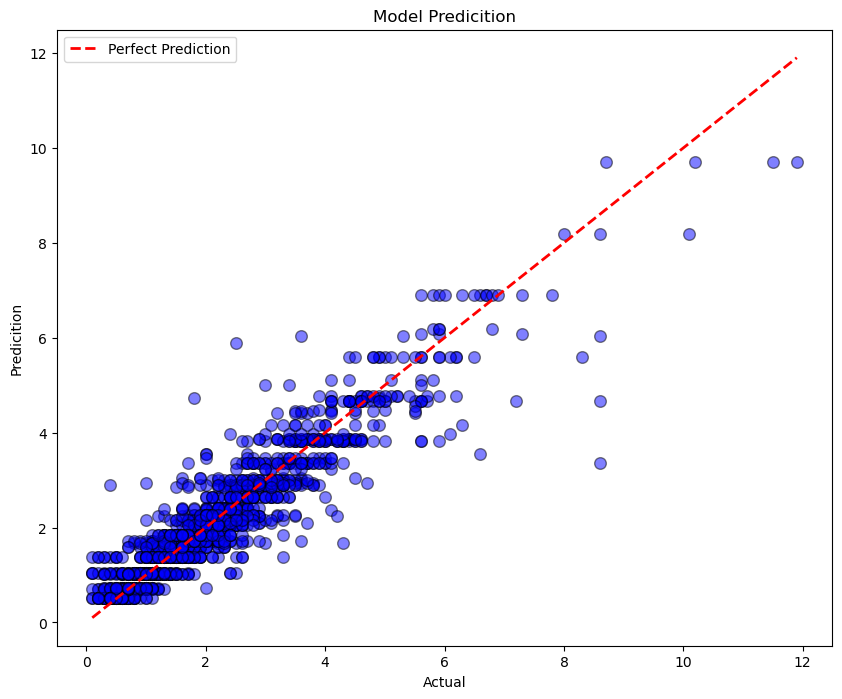

In [161]:
y_pred = best_model.predict(X_test)
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, s=70, color='blue', edgecolor='k', alpha=0.5)
plt.title('Model Predicition')
line_coords = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicition')
plt.show()

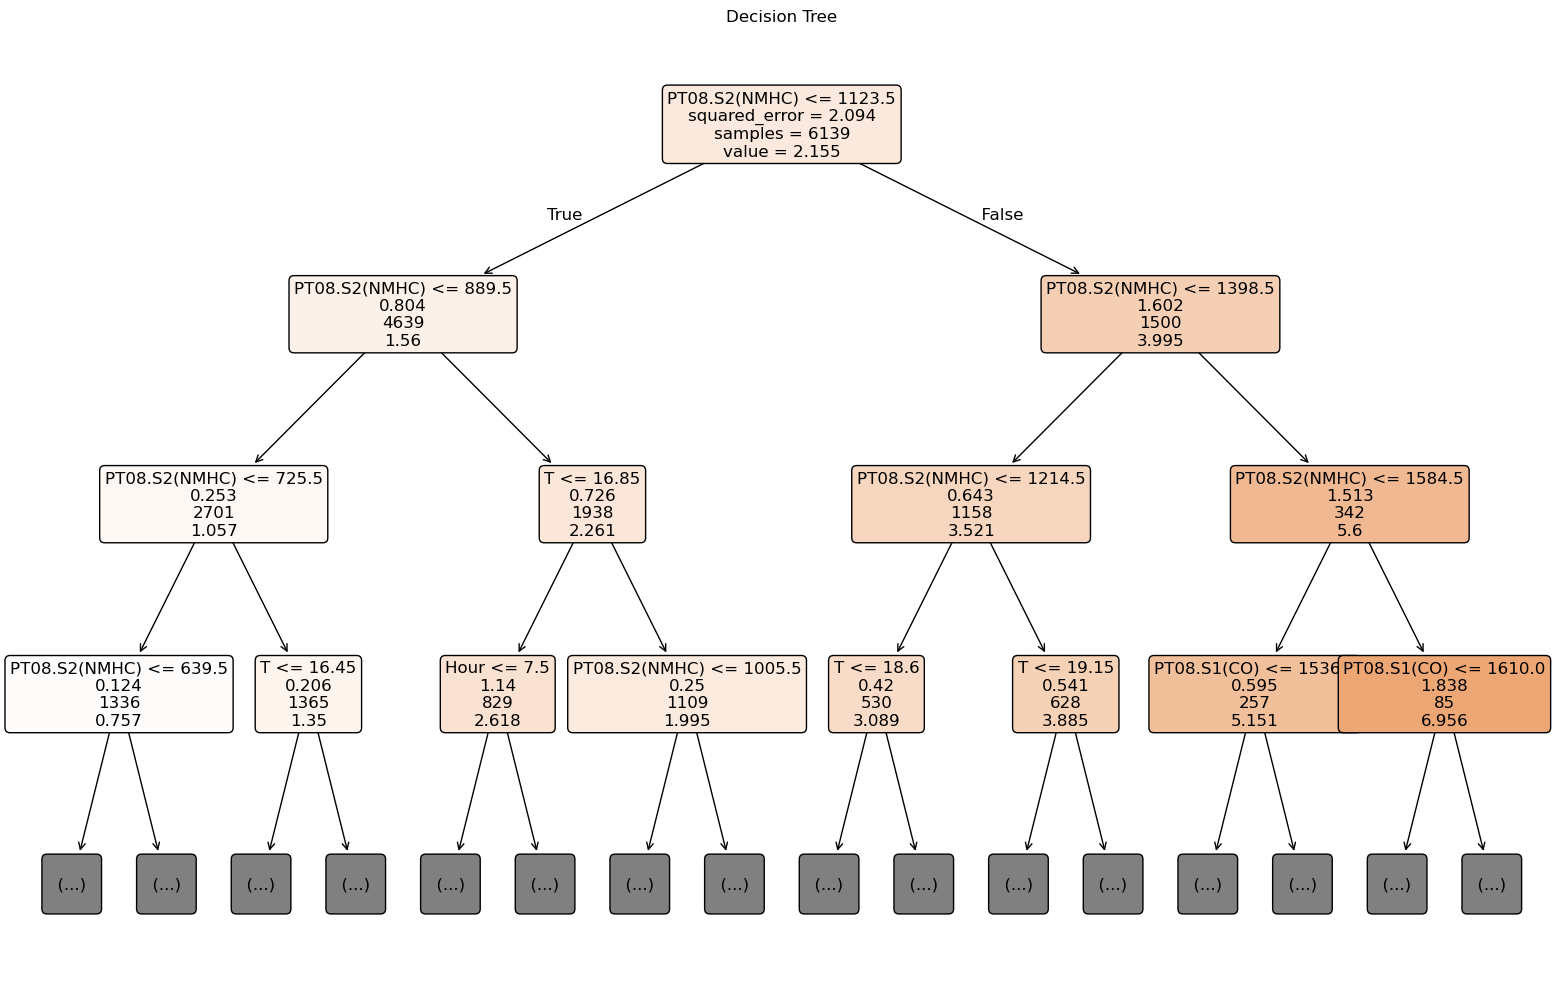

In [171]:
plt.figure(figsize=(16,10))
plot_tree(
    best_model.named_steps['Model'],
    feature_names=X_train.columns,
    max_depth=3,
    rounded=True,
    filled=True,
    label='root',
    fontsize=12,
    class_names=['CO(GT)']
)
plt.title('Decision Tree', fontsize=12)
plt.tight_layout()
plt.show()

In [178]:
feature_importance = best_model.named_steps['Model'].feature_importances_
feature_df = pd.DataFrame(
    data={
        'Feature Names': X_train.columns,
        'Feature Importance': feature_importance
    }
).sort_values(by='Feature Importance', ascending=False)
feature_df
    

,Feature Names,Feature Importance
1,PT08.S2(NMHC),0.903827
5,T,0.044686
0,PT08.S1(CO),0.021774
8,Hour,0.014483
4,PT08.S5(O3),0.005274
9,Month,0.005198
3,PT08.S4(NO2),0.002616
7,AH,0.002142
2,PT08.S3(NOx),0.000000
6,RH,0.000000


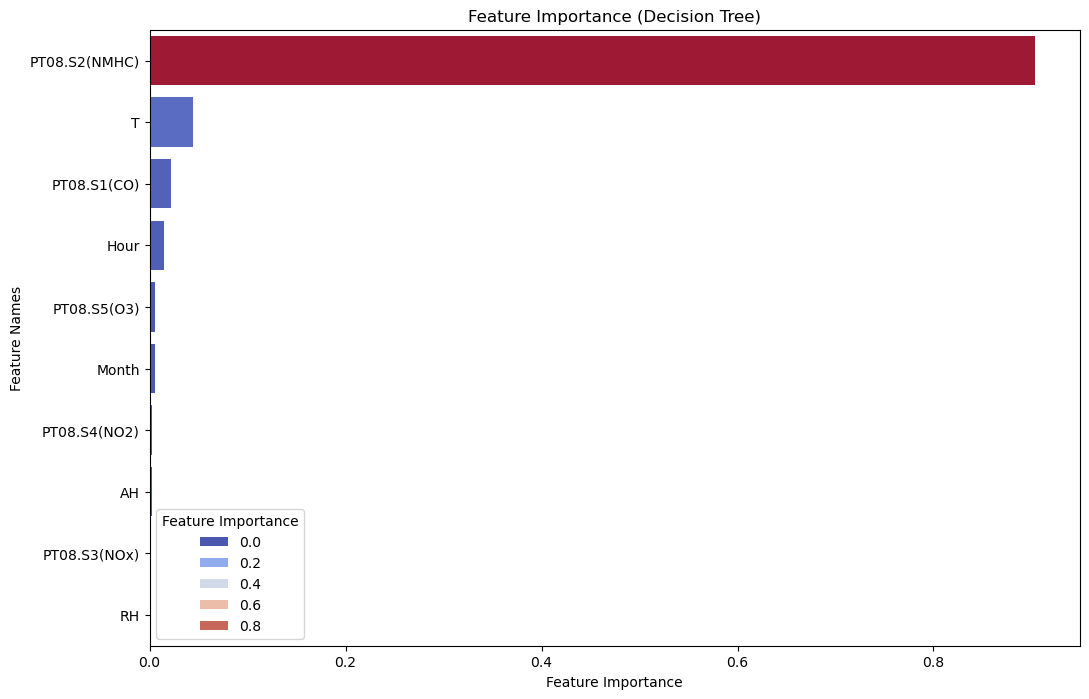

In [184]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=feature_df,
    y='Feature Names',
    x='Feature Importance',
    hue='Feature Importance',
    palette='coolwarm',
    orient='h'
)
plt.title('Feature Importance (Decision Tree)')
plt.show()